In [1]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [2]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_imgs(imgs, x_crop, y_crop, mask)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop .* mask)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, dict_set_val_sat, intensities_imgs, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if dict_set_val_sat[intensities_imgs[i]] >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets_range)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end
    
    blobs = response .> threshold_droplets_range * std(img)^(1/2) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

In [15]:
pathdir = "Y:/TwoDGas/2026/01/19/0047"
I_set_value = [0.1:0.1:1;]
sat_exp = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # Estimated saturation parameter
dict_set_val_sat = Dict(I_set_value[i] => sat_exp[i] for i in eachindex(I_set_value))

τ_exp = 5e-6 # In s
x_crop = [1255:1575;]
y_crop = [1890:2260;]
wrong_shots = [1, 2, 3, 4, 11, 21, 31, 41]
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

N_atoms_per_droplet = 15000
radius_droplets = 14 # In pxls

xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;

In [16]:
if !isdir("imgs")
    mkdir("imgs")
end

if !isdir("imgs/"*join(split(pathdir, "/")[3:5], "_"))
    mkdir("imgs/"*join(split(pathdir, "/")[3:5], "_"))
end

if !isdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end])
    mkdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end])
end

if !isdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask")
    mkdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask")
    mkdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/droplets")
    mkdir("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/droplets")
end

# Import and crop the images

In [17]:
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

files_path = readdir(pathdir)

imgs_atoms, imgs_bkg, imgs_dark, intensities_imgs = load_imgs(files_path, pathdir)
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets = crop_imgs(imgs_atoms, x_crop, y_crop, mask), crop_imgs(imgs_bkg, x_crop, y_crop, mask), crop_imgs(imgs_dark, x_crop, y_crop, mask);

In [18]:
@save "Imgs_crop_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets intensities_imgs

In [19]:
@load "Imgs_crop_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets intensities_imgs;

# Compute the ODs

In [20]:
ODs_dataset = compute_OD_high_low_intensity(imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets, dict_set_val_sat, intensities_imgs, τ_exp);

In [21]:
@save "ODs_crop_mask.jld2" ODs_dataset

In [22]:
@load "ODs_crop_mask.jld2" ODs_dataset;

# Save the ODs images

### ODs

In [23]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:00<00:20, 2it/s]
6.0%┣██▉                                             ┫ 3/50 [00:01<00:17, 3it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:13, 3it/s]
10.0%┣████▊                                          ┫ 5/50 [00:01<00:11, 4it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:01<00:10, 4it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:01<00:09, 5it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:01<00:09, 5it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:02<00:08, 5it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:02<00:08, 5it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:02<00:07, 5it/s]
24.0%┣███████████           

### Negative ODs

In [24]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:00<00:15, 3it/s]
6.0%┣██▉                                             ┫ 3/50 [00:00<00:10, 4it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:09, 5it/s]
10.0%┣████▊                                          ┫ 5/50 [00:01<00:09, 5it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:01<00:08, 5it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:01<00:07, 6it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:01<00:07, 6it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:01<00:07, 6it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:01<00:06, 6it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:02<00:06, 6it/s]
24.0%┣███████████           

# Count the droplets

In [25]:
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;]
threshold_droplets_range = 8000000
# threshold_droplets_range = 800000
nbr_droplets = zeros(length(ODs_dataset))
centers_droplets = []
save_imgs = true

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
    centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

    if save_imgs
        axs[1].imshow(smooth_norm_OD)
        axs[2].imshow(label_blobs)
        axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
        axs[3].imshow(OD)
        axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)
        
        for c in centers
            circle = plt.Circle(((c[1], c[2])), radius_droplets, color="r", fill=false)
            axs[3].add_patch(circle)
        end


        savefig("imgs/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/droplets/$(i-1).png")
        for ax in axs
            ax.clear()
        end
    end

    nbr_droplets[i] = length(centers)
    push!(centers_droplets, centers)
end

close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:01<00:31, 2it/s]
6.0%┣██▉                                             ┫ 3/50 [00:01<00:22, 2it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:18, 3it/s]
10.0%┣████▊                                          ┫ 5/50 [00:02<00:18, 3it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:02<00:16, 3it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:02<00:15, 3it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:02<00:14, 3it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:03<00:14, 3it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:03<00:13, 3it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:03<00:13, 3it/s]
24.0%┣███████████           

# Compute the integrated intensity of each droplet

In [26]:
function masked_droplets(img, centers, radius_droplets, x_crop, y_crop)
    mask = zeros(size(img))
    for c in centers
        mask .+= mask_ellipse(c[1], c[2], radius_droplets, radius_droplets, 0, x_crop, y_crop)
    end
    mask[mask .> 0] .= true
    return img.*mask
end

masked_droplets (generic function with 1 method)

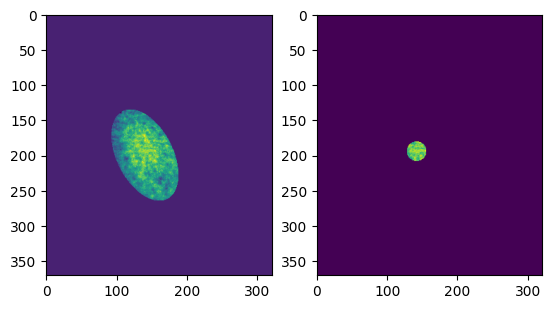

false

In [27]:
close("all")
fig, axs = subplots(1, 2)

axs[1].imshow(ODs_dataset[5])
axs[2].imshow(masked_droplets(ODs_dataset[5], centers_droplets[5], radius_droplets, x_crop, y_crop))

# pygui(true); show()
pygui(false)

In [28]:
Iatoms_drop, Ibkg_drop, Idark_drop = zeros(length(ODs_dataset)), zeros(length(ODs_dataset)), zeros(length(ODs_dataset))

Convertion_factor = (0.85 * 0.107 * τ_exp)

for i in ProgressBar(1:length((imgs_atoms_crop_datasets)))
    centers_drops = centers_droplets[i]
    if (i ∉ wrong_shots) & (nbr_droplets[i] > 0)
        Iatoms_drop[i] = sum(masked_droplets(imgs_atoms_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/nbr_droplets[i]
        Ibkg_drop[i] = sum(masked_droplets(imgs_bkg_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/nbr_droplets[i]
        Idark_drop[i] = sum(masked_droplets(imgs_dark_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/nbr_droplets[i]
    end
end

Iatoms_drop /= N_atoms_per_droplet*Convertion_factor
Ibkg_drop /= N_atoms_per_droplet*Convertion_factor
Idark_drop /= N_atoms_per_droplet*Convertion_factor;

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
10.0%┣████▋                                         ┫ 5/50 [00:00<00:03, 15it/s]
14.0%┣██████▍                                       ┫ 7/50 [00:00<00:02, 19it/s]
18.0%┣████████▎                                     ┫ 9/50 [00:00<00:02, 21it/s]
20.0%┣█████████                                    ┫ 10/50 [00:00<00:02, 20it/s]
32.0%┣██████████████▍                              ┫ 16/50 [00:01<00:01, 29it/s]
36.0%┣████████████████▏                            ┫ 18/50 [00:01<00:01, 28it/s]
40.0%┣██████████████████                           ┫ 20/50 [00:01<00:01, 28it/s]
50.0%┣██████████████████████▌                      ┫ 25/50 [00:01<00:01, 32it/s]
56.0%┣█████████████████████████▏                   ┫ 28/50 [00:01<00:01, 31it/s]
60.0%┣███████████████████████████                  ┫ 30/50 [00:01<00:01, 28it/s]
74.0%┣█████████████████████████████████▎           ┫ 37/50 [00:01<00:00, 33it/s]
78.0%┣██████████████████████

In [29]:
Iatoms_drop_per_sat, Ibkg_drop_per_sat, Idark_drop_per_sat = zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp))))

for i in 1:length(Iatoms_drop)
    if i ∉ wrong_shots
        idx = findfirst(==(intensities_imgs[i]), I_set_value)
        # println("$i $idx $(floor(Int64, ((i-1)/length(I_set_value)+1)))")
        Iatoms_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Iatoms_drop[i]
        Ibkg_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Ibkg_drop[i]
        Idark_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Idark_drop[i]
    end
end

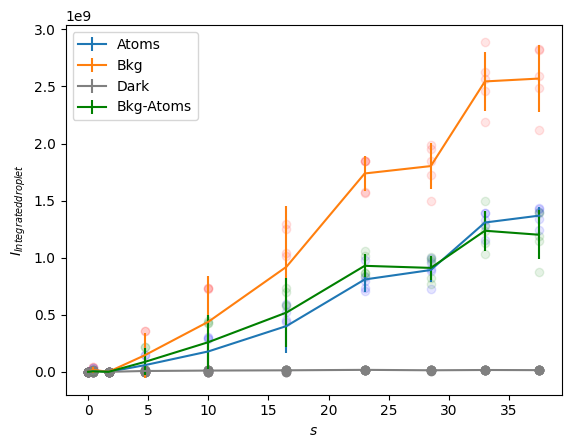

In [30]:
close("all")
fig = subplots()

# errorbar(sat_exp)

errorbar(sat_exp, vec(mean(Iatoms_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_drop_per_sat, dims = 2)), label="Atoms")
errorbar(sat_exp, vec(mean(Ibkg_drop_per_sat, dims = 2)), yerr=vec(std(Ibkg_drop_per_sat, dims = 2)), label="Bkg")
errorbar(sat_exp, vec(mean(Idark_drop_per_sat, dims = 2)), yerr=vec(std(Idark_drop_per_sat, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp, vec(mean(Ibkg_drop_per_sat, dims = 2))-vec(mean(Iatoms_drop_per_sat, dims = 2)), yerr=vec(std(Ibkg_drop_per_sat-Iatoms_drop_per_sat, dims = 2)), label="Bkg-Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i], color="b", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i], color="r", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i]-Iatoms_drop[i], color="g", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Idark_drop[i], color="grey")
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()

# pygui(true); show();
pygui(false);

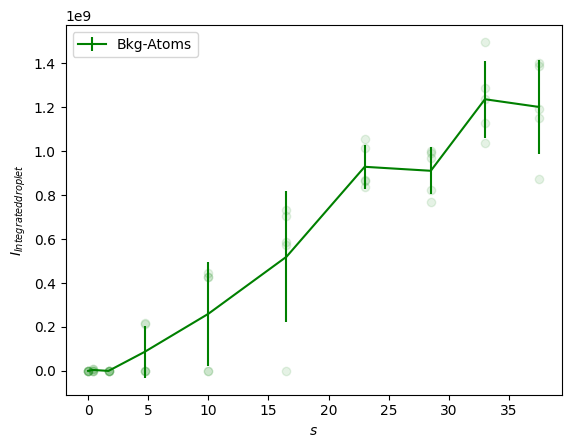

In [31]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Ibkg_drop_per_sat, dims = 2))-vec(mean(Iatoms_drop_per_sat, dims = 2)), yerr=vec(std(Ibkg_drop_per_sat-Iatoms_drop_per_sat, dims = 2)), label="Bkg-Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i]-Iatoms_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()

# pygui(true); show();
pygui(false);

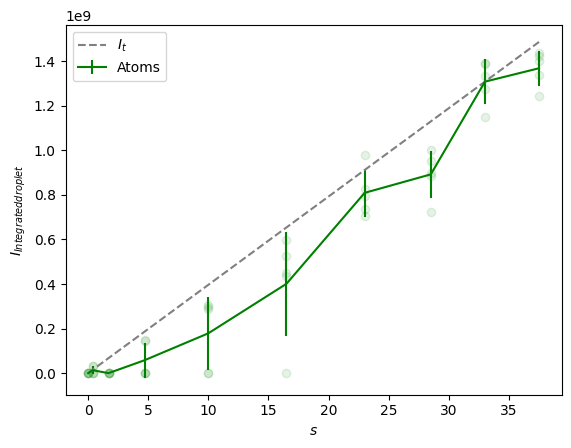

In [32]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_drop_per_sat, dims = 2)), label="Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

function It(s, sat_exp, Iatoms_drop_per_sat)
    return mean(Iatoms_drop_per_sat, dims = 2)[end-1]/sat_exp[end-1] .* s
end

It_range = It(sat_exp, sat_exp, Iatoms_drop_per_sat)
plot(sat_exp, It_range, linestyle="--", color="grey", label=L"I_t")

legend()

# pygui(true); show();
pygui(false);

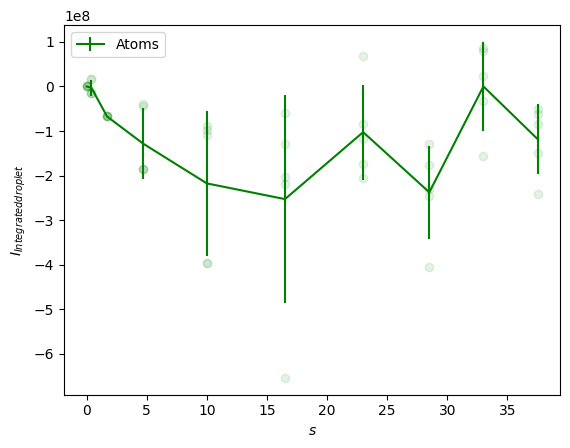

In [33]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_drop_per_sat, dims = 2)) - It_range, yerr=vec(std(Iatoms_drop_per_sat, dims = 2)), label="Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i] - It_range[findfirst(==(intensities_imgs[i]), I_set_value)], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()


# pygui(true); show();
pygui(false);